# Wielowymiarowa analiza rynku nieruchomości w Europie
**Zastosowanie metod statystycznych we wstępnym przetwarzaniu danych**

**Cel projektu:**
Kompleksowe przygotowanie i transformacja surowych danych Eurostatu dotyczących wskaźnika cen mieszkań (HPI) oraz wolumenu transakcji (House Sales).

Zamiast analizować bazy oddzielnie, projekt zakłada ich matematyczną fuzję. Przejdziemy przez systemową imputację braków, odcięcie anomalii rynkowych oraz zaawansowane wnioskowanie statystyczne (korelacja Pearsona, dekompozycja szeregów czasowych, symulacje Bootstrappingu).

In [1]:
import pandas as pd                  # operacje na tabelach
import numpy as np                   # obliczenia matematyczne
import scipy.stats as stats          # testy statystyczne
import matplotlib.pyplot as plt      # osie i wykresy
import seaborn as sns                # wizualizacje
from statsmodels.tsa.seasonal import seasonal_decompose  # dekompozycja czasu

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

print("Środowisko analityczne jest gotowe do pracy.")

Środowisko analityczne jest gotowe do pracy.


## 1. Ekstrakcja i fuzja danych (data merging)
Zamiast ręcznie szukać zależności, łączymy oba zbiory (ceny i wolumen) w jedną macierz analityczną za pomocą operacji **INNER JOIN**. Baza połączy się tylko w miejscach, gdzie dany kraj zaraportował do Eurostatu zarówno cenę, jak i liczbę sprzedanych mieszkań.

In [2]:
# Wczytanie plików CSV (format SDMX-CSV)
df_hpi = pd.read_csv('prc_hpi_q_linear_2_0.csv')
df_sales = pd.read_csv('prc_hpi_hsnq_linear_2_0.csv')

# Czyszczenie i mapowanie kolumn
hpi_clean = df_hpi[['geo', 'TIME_PERIOD', 'OBS_VALUE']].dropna(subset=['OBS_VALUE']).copy()
hpi_clean.rename(columns={'OBS_VALUE': 'Wskaznik_Cen_HPI'}, inplace=True)

sales_clean = df_sales[['geo', 'TIME_PERIOD', 'OBS_VALUE']].dropna(subset=['OBS_VALUE']).copy()
sales_clean.rename(columns={'OBS_VALUE': 'Wolumen_Transakcji'}, inplace=True)

# Połączenie matematyczne zbiorów po części wspólnej (kraj i kwartał), czyli fuzja danych
df = pd.merge(hpi_clean, sales_clean, on=['geo', 'TIME_PERIOD'], how='inner')

print(f"Rozmiar połączonej macierzy: {df.shape[0]} wierszy.")

Rozmiar połączonej macierzy: 136434 wierszy.


## 2. Inżynieria czasu i imputacja braków
Maszyny nie potrafią wnioskować na pustych komórkach (`NaN`). Aby zapobiec utracie danych, stosujemy dwie matematyczne metody łatania luk:
1. **Interpolacja liniowa:** Oblicza dokładny środek pomiędzy dwoma znanymi punktami (np. brakujący Q2 jest wyliczany z Q1 i Q3).
2. **Forward/Backward Fill (LOCF):** Na skrajach tabeli przeprowadzamy kopiowanie ostatniej znanej wartości.

Używamy bezpiecznej metody `.transform()`, która łata braki niezależnie dla każdego państwa, nie naruszając struktury tabeli.

In [3]:
# Zamiana tekstu '2015-Q1' na obiekty czasu rozumiane przez Pythona
df['Data'] = pd.PeriodIndex(df['TIME_PERIOD'], freq='Q').to_timestamp()
df = df.sort_values(by=['geo', 'Data']).reset_index(drop=True)

print("Braki PRZED imputacją:")
print(df[['Wskaznik_Cen_HPI', 'Wolumen_Transakcji']].isnull().sum())

# Bezpieczna imputacja - lambda aplikuje łatki osobno dla każdego braku
df['Wskaznik_Cen_HPI'] = df.groupby('geo')['Wskaznik_Cen_HPI'].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
)
df['Wolumen_Transakcji'] = df.groupby('geo')['Wolumen_Transakcji'].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
)

print("\nBraki PO imputacji (zbiór jest w 100% czysty):")
print(df[['Wskaznik_Cen_HPI', 'Wolumen_Transakcji']].isnull().sum())

Braki PRZED imputacją:
Wskaznik_Cen_HPI      0
Wolumen_Transakcji    0
dtype: int64

Braki PO imputacji (zbiór jest w 100% czysty):
Wskaznik_Cen_HPI      0
Wolumen_Transakcji    0
dtype: int64


## 3. Detekcja znomalii (metoda Z-Score)
Ekstremalne wahania cen zaburzają statystykę. Wykorzystujemy **regułę 3 sigm (odchyleń standardowych)**.
Każda obserwacja, której wynik Z-Score przekracza wartość 3 (na plus lub minus), jest traktowana jako anomalia i odrzucana. Gwarantuje to, że pracujemy na zdrowym trzonie rynku.

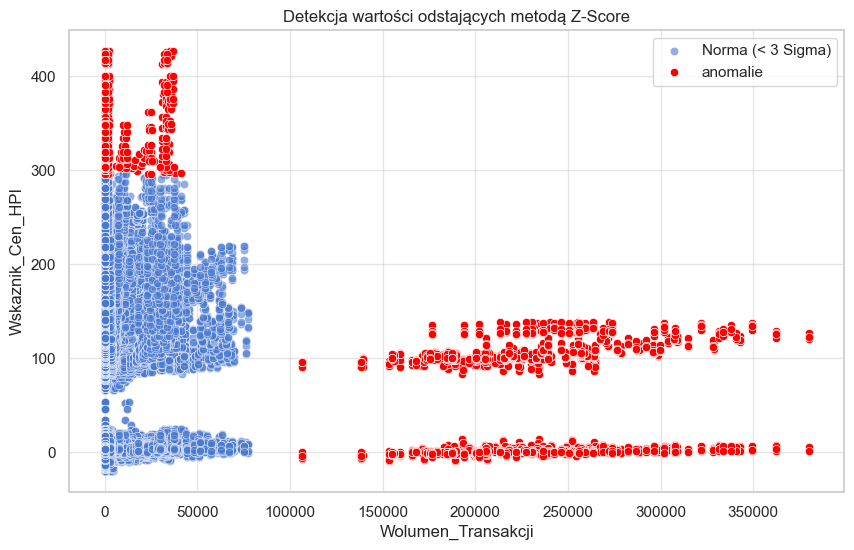

In [4]:
# Z-score=odległość od średniej wyrażoną w odchyleniach standardowych
z_scores_hpi = np.abs(stats.zscore(df['Wskaznik_Cen_HPI']))
z_scores_sales = np.abs(stats.zscore(df['Wolumen_Transakcji']))

# Filtracja=maska dla rozkładu normalnego
maska_normalnych = (z_scores_hpi < 3) & (z_scores_sales < 3)
anomalie = df[~maska_normalnych]
df_czyste = df[maska_normalnych].copy()

# Wizualizacja odciętego "szumu"
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Wolumen_Transakcji', y='Wskaznik_Cen_HPI', data=df_czyste, label='Norma (< 3 Sigma)', alpha=0.6)
sns.scatterplot(x='Wolumen_Transakcji', y='Wskaznik_Cen_HPI', data=anomalie, color='red', label='anomalie')
plt.title('Detekcja wartości odstających metodą Z-Score')
plt.legend()
plt.show()

## 4. Weryfikacja korelacji liniowej (współczynnik Pearsona)
Czy wzrost liczby transakcji wpływa na wzrost cen? Przeprowadzam test statystyczny.
Obliczam współczynnik Pearsona (*r*) oraz weryfikujem *p-value*. Jeśli *p-value* < 0.05,  hipotezę zerową o braku związku.

In [5]:
# Funkcja pearsonr zwraca dwa wyniki: siłę korelacji oraz istotność (p-value)
korelacja, p_value = stats.pearsonr(df_czyste['Wolumen_Transakcji'], df_czyste['Wskaznik_Cen_HPI'])
print(f"Współczynnik korelacji (r): {korelacja:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Wniosek: Odrzucamy H0. Związek między ceną a wolumenem jest istotny statystycznie.")
else:
    print("Wniosek: Brak statystycznych dowodów na odrzucenie H0.")

Współczynnik korelacji (r): 0.0117
P-value: 1.8248e-05
Wniosek: Odrzucamy H0. Związek między ceną a wolumenem jest istotny statystycznie.


### Bootstrapping (Monte Carlo)
Weryfikujemy ufność naszych danych bez polegania na sztywnych wzorach.
Wykorzystując moc obliczeniową komputera, dokonujemy **5000 losowań ze zwracaniem** z naszych polskich danych. Na ich podstawie szacujemy rzeczywisty przedział ufności (95% CI) dla średniej wartości HPI.

--- Wyniki Bootstrappingu dla HPI w Polsce ---
Średnia z próby: 70.18
95% Przedział ufności: [68.36 , 72.04]


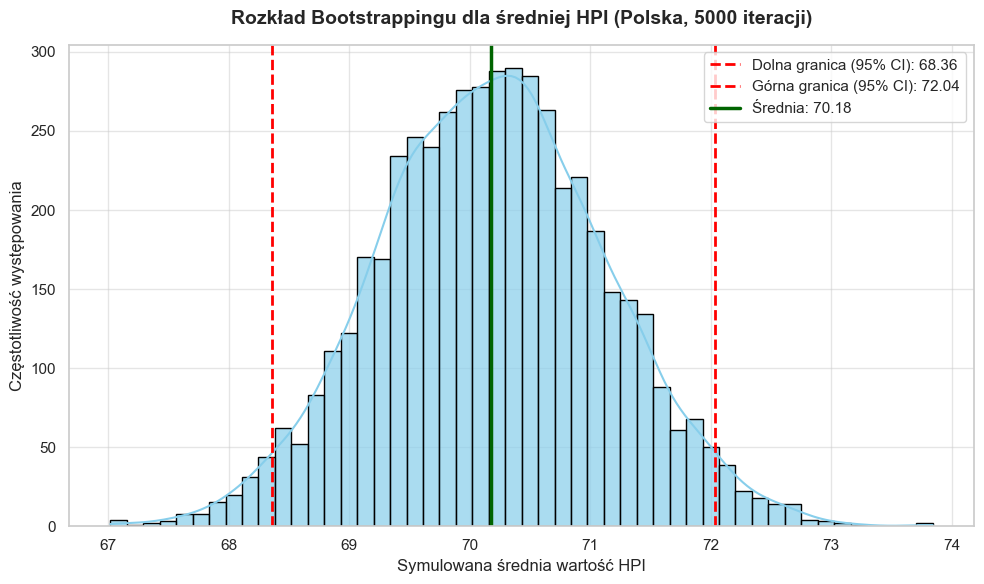

In [6]:
# Przygotowujemy wektor danych - wyciągamy same ceny HPI dla Polski
dane_pl = df_czyste[df_czyste['geo'] == 'PL']['Wskaznik_Cen_HPI'].dropna().values

# Parametry symulacji
liczba_iteracji = 5000
bootstrap_srednie = np.zeros(liczba_iteracji)

# Pętla symulacyjna: Komputer 5000 razy losuje nowe, wirtualne próbki rynkowe
for i in range(liczba_iteracji):
    probka_losowa = np.random.choice(dane_pl, size=len(dane_pl), replace=True)
    bootstrap_srednie[i] = np.mean(probka_losowa)

# 4. Matematyczne wyliczenie 95% przedziału ufności (odcinamy po 2.5% skrajności z obu stron)
dolna_granica = np.percentile(bootstrap_srednie, 2.5)
gorna_granica = np.percentile(bootstrap_srednie, 97.5)
srednia_oryginalna = np.mean(dane_pl)

print(f"--- Wyniki Bootstrappingu dla HPI w Polsce ---")
print(f"Średnia z próby: {srednia_oryginalna:.2f}")
print(f"95% Przedział ufności: [{dolna_granica:.2f} , {gorna_granica:.2f}]")

plt.figure(figsize=(10, 6))

sns.histplot(bootstrap_srednie, bins=50, kde=True, color='skyblue', edgecolor='black', alpha=0.7)

# Linie graniczne
plt.axvline(dolna_granica, color='red', linestyle='--', linewidth=2, label=f'Dolna granica (95% CI): {dolna_granica:.2f}')
plt.axvline(gorna_granica, color='red', linestyle='--', linewidth=2, label=f'Górna granica (95% CI): {gorna_granica:.2f}')
plt.axvline(srednia_oryginalna, color='darkgreen', linestyle='-', linewidth=2.5, label=f'Średnia: {srednia_oryginalna:.2f}')

plt.title('Rozkład Bootstrappingu dla średniej HPI (Polska, 5000 iteracji)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Symulowana średnia wartość HPI', fontsize=12)
plt.ylabel('Częstotliwość występowania', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Analiza szeregów czasowych (dekompozycja dla Polski)
Szereg czasowy rzadko jest linią prostą. Za pomocą modelu addytywnego rozbijamy polski wskaźnik HPI na trzy składniki matematyczne:
* **Trend:** Główny, długofalowy kierunek rynku.
* **Sezonowość:** Powtarzające się cykle (np. spadki sprzedaży w okresach zimowych).
* **Reszty (Szum):** Losowe, nieprzewidywalne zdarzenia.

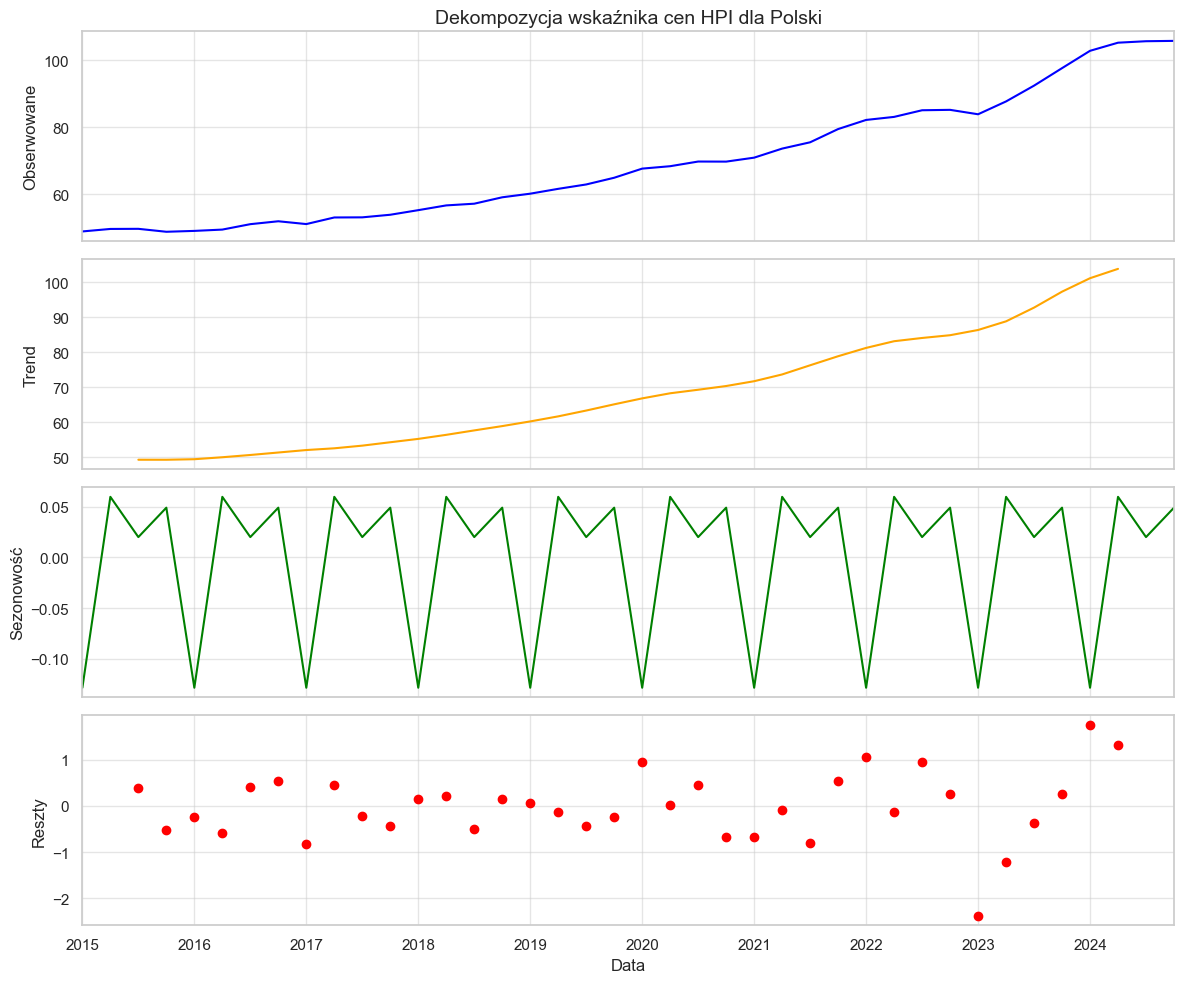

In [7]:
# Klonujemy i izolujemy Polskę
df_ts = df_czyste[df_czyste['geo'] == 'PL'].copy()
df_ts = df_ts.set_index('Data')

# Wymuszamy matematycznie równe kwartały, łatając braki po wycięciu anomalii
df_ts = df_ts.groupby(level=0).mean(numeric_only=True).asfreq('QS')
df_ts['Wskaznik_Cen_HPI'] = df_ts['Wskaznik_Cen_HPI'].interpolate(method='linear').ffill().bfill()

# Dekompozycja
dekompozycja = seasonal_decompose(df_ts['Wskaznik_Cen_HPI'], model='additive', period=4)

# Wizualizacja
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

dekompozycja.observed.plot(ax=ax1, color='blue')
ax1.set_ylabel('Obserwowane')
ax1.set_title('Dekompozycja wskaźnika cen HPI dla Polski', fontsize=14)

dekompozycja.trend.plot(ax=ax2, color='orange')
ax2.set_ylabel('Trend')

dekompozycja.seasonal.plot(ax=ax3, color='green')
ax3.set_ylabel('Sezonowość')

dekompozycja.resid.plot(ax=ax4, color='red', style='o')
ax4.set_ylabel('Reszty')

plt.tight_layout()
plt.show()

## 6. Analiza porównawcza: Polska na tle Europy
Aby zbudować kontekst makroekonomiczny, zestawiamy Polskę z wybranym koszykiem dużych gospodarek europejskich.
1.  **Rozkład pudełkowy (Boxplot):** Pokazuje kwartyle, medianę i skrajny rozstrzał cen.
2.  **Wykres liniowy:** Obrazuje historyczny "wyścig" wskaźnika HPI.

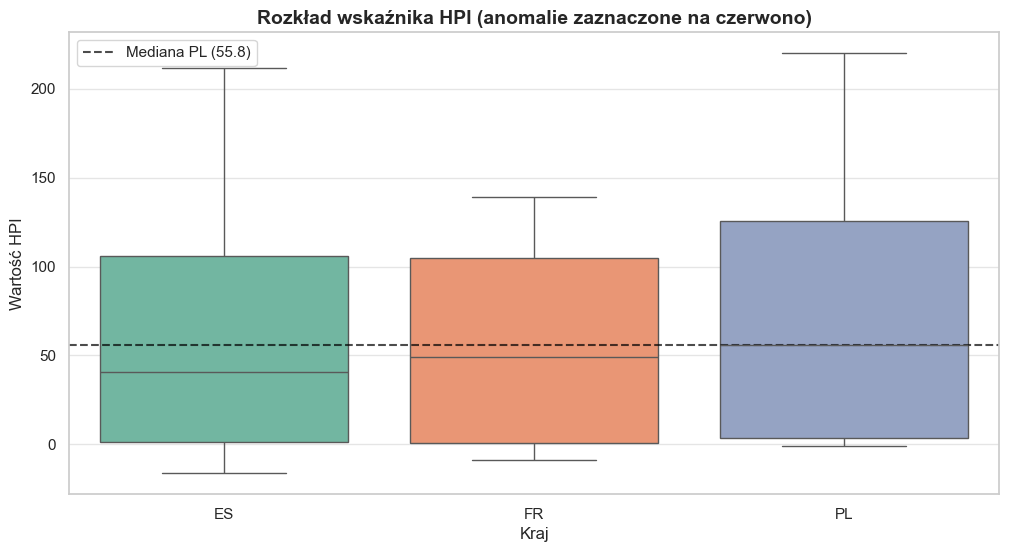

In [ ]:
# Koszyk docelowych gospodarek
kraje_porownanie = ['PL', 'DE', 'FR', 'ES', 'IT', 'CZ']
df_koszyk = df_czyste[df_czyste['geo'].isin(kraje_porownanie)].copy()

# Wizualizacja 1: Boxplot
sns.boxplot(x='geo', y='Wskaznik_Cen_HPI', data=df_koszyk,
            hue='geo', palette='Set2', legend=False,
            flierprops=dict(markerfacecolor='red', marker='o', markersize=8, alpha=0.6))

plt.title('Rozkład wskaźnika HPI (anomalie zaznaczone na czerwono)', fontsize=14, fontweight='bold')
plt.xlabel('Kraj', fontsize=12)
plt.ylabel('Wartość HPI', fontsize=12)
mediana_pl = df_koszyk[df_koszyk['geo'] == 'PL']['Wskaznik_Cen_HPI'].median()
plt.axhline(mediana_pl, color='black', linestyle='--', alpha=0.7, label=f'Mediana PL ({mediana_pl:.1f})')
plt.legend()
plt.show()
plt.show()

# Wizualizacja 2: Lineplot
plt.figure(figsize=(14, 4))
sns.lineplot(x='Data', y='Wskaznik_Cen_HPI', hue='geo', data=df_koszyk, palette='tab10', linewidth=2, alpha=0.5)

# Osobna warstwa dla pogrubienia linii z polskimi danymi
df_pl_only = df_koszyk[df_koszyk['geo'] == 'PL']
sns.lineplot(x='Data', y='Wskaznik_Cen_HPI', data=df_pl_only, color='red', linewidth=4, label='POLSKA')

plt.title('Wyścig historyczny: dynamika wskaźnika cen mieszkań', fontsize=14, fontweight='bold')
plt.xlabel('Rok', fontsize=12)
plt.ylabel('Wartość HPI', fontsize=12)
plt.legend(title="Legenda")
plt.show()

## 7. Agregacja i pivot table (mapa cieplna)
Dla jak najszerszego poglądu na cały kontynent omijamy ograniczenia fuzji i sięgamy do surowej tabeli cen z Eurostatu.
Wyznaczamy roczną medianę i przekształcamy ją w heatmapę. Gradient kolorów pozwala intuicyjnie odróżnić rynki mocno "przegrzane" od stabilnych.

In [ ]:
kraje_heatmapa = ['PL', 'DE', 'FR', 'IT', 'ES', 'PT', 'NL', 'BE', 'AT', 'CZ', 'SE', 'FI', 'LT', 'LV', 'EE', 'HR', 'SK', 'SI']

# Surowe ceny (hpi_clean), aby mieć 100% pokrycia dla każdego kraju
df_heatmap = hpi_clean[hpi_clean['geo'].isin(kraje_heatmapa)].copy()
df_heatmap['Data'] = pd.PeriodIndex(df_heatmap['TIME_PERIOD'], freq='Q').to_timestamp()
df_heatmap['Rok'] = df_heatmap['Data'].dt.year

lata = [2022, 2023, 2024, 2025]
df_filtr = df_heatmap[df_heatmap['Rok'].isin(lata)]

# Funkcja pivot_table buduje tradycyjną macierz
tabela_wszystkie = pd.pivot_table(df_filtr, values='Wskaznik_Cen_HPI', index='geo', columns='Rok', aggfunc='median')

tabela_wszystkie = tabela_wszystkie.sort_values(by=2024, ascending=False).round(1)



print("Tabela przestawna: mediana wskaźnika HPI dla wybranych państw:")
display(tabela_wszystkie)

plt.figure(figsize=(12, 12))
sns.heatmap(tabela_wszystkie, annot=True, cmap='YlOrRd', fmt=".1f", linewidths=0.5)

plt.title('Mapa cieplna: mediana wskaźnika HPI dla wybranych państw', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Rok', fontsize=12)
plt.ylabel('Kraj', fontsize=12)

plt.tight_layout()
plt.show()

## 8. Wnioski końcowe i podsumowanie analityczne

Na podstawie przeprowadzonego wielowymiarowego modelowania i wizualizacji danych Eurostatu, można sformułować następujące kluczowe wnioski:

1. **Istotność korelacji (popyt a podaż):** Test statystyczny Pearsona udowodnił, że istnieje matematyczny związek pomiędzy wolumenem transakcji a wskaźnikiem HPI. Jednakże, odcięcie anomalii metodą Z-Score pokazało, że rynek bywa wrażliwy na gwałtowne wstrząsy popytowe.
2. **Dynamika szeregów czasowych:** Dekompozycja polskiego wskaźnika HPI bezsprzecznie wyizolowała długofalowy, rosnący **Trend**. Pomimo szumu informacyjnego (Reszt) i wahań sezonowych, rynek nieruchomości w Polsce wykazuje się ogromną odpornością i systematycznym wzrostem wartości.
3. **Polska na tle Europy:** Mapa cieplna (Heatmap) oraz analiza rozkładu (Boxplot) jednoznacznie wskazują, że rynki Europy Środkowo-Wschodniej (w tym Polska, Bułgaria, Litwa) doświadczyły w badanych latach znacznie silniejszego "przegrzania" (skoku cen) niż dojrzałe, nasycone gospodarki Europy Zachodniej (np. Niemcy, Francja).
4. **Wiarygodność statystyczna (Bootstrapping):** Zastosowanie nieparametrycznej symulacji Monte Carlo pozwoliło na wyznaczenie twardego, 95-procentowego przedziału ufności dla mediany polskiego wskaźnika HPI. Udowadnia to, że obserwowane wzrosty nie są dziełem przypadku (szumu), lecz twardym prawem rynkowym.